In [ ]:
%pip install -Uq numpy pandas matplotlib seaborn pyomo

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


# RRS Logistics Network — Two-Stage Stochastic Capacity Planning

## Business Problem

RiRiShun Logistics (RRS) operates a multi-echelon distribution network of **103 centers** across China. Orders for home appliances — bulky, heterogeneous products — must travel from Origin Centers through optional Transfer Centers to Destination Centers before reaching consumers. Each center-to-center leg requires **linehaul capacity** (truck space) that must be reserved *before* demand is known.

The fundamental tension is this:
- **Too little reserved capacity** → missed delivery commitments and costly emergency rerouting.
- **Too much reserved capacity** → wasted money on unused slots.

> **Decision question:** Given uncertain future demand, how much capacity should RRS reserve on each center-to-center arc, and across which load classes, so that delivery commitments are met at minimum expected cost?

## Modeling Approach

We formulate this as a **two-stage stochastic linear program (SP)**:

1. **First stage (here-and-now):** Reserve linehaul capacity $C_{a,\ell}$ on each arc $a$ for load class $\ell$, paying a distance-weighted reservation cost — before demand is observed.
2. **Second stage (wait-and-see):** After demand scenario $s$ materialises, decide actual freight flows $f_{a,\ell,s}$ and absorb any unmet demand $u_{a,\ell,s}$ at a penalty.

The objective minimises reservation cost plus *expected* operating and service-failure cost across all demand scenarios.

## Run Instructions

1. Place `demand_stats.csv`, `scenarios.csv`, and `demand_by_load.csv` in the same directory as this notebook.
2. Install dependencies (first cell above).
3. Install GLPK: `sudo apt install glpk-utils` (Linux) or `brew install glpk` (Mac).
4. **Kernel → Restart & Run All** — all outputs are fully reproducible (seed fixed to 42).

## 1. Imports and Global Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

import pyomo.environ as pyo
from pyomo.opt import SolverFactory

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Solver ────────────────────────────────────────────────────────
opt = SolverFactory("glpk")

# ── Cost coefficients ─────────────────────────────────────────────
# All costs are in normalised monetary units per kilogram.
# Costs scale with arc distance (km) to proxy transportation effort.
COST_PER_KM_PER_KG = 0.001   # 1st-stage: capacity reservation cost (£/kg/km)
TRANSPORT_SCALE    = 0.002   # 2nd-stage: actual flow cost (£/kg/km)
PENALTY_RATIO      = 10.0    # Unmet-demand penalty multiplier (× transport cost)

# ── Data filtering ────────────────────────────────────────────────
MIN_WEEKS_OBSERVED = 10      # Minimum weeks of history for an arc to be included

# ── Scenario split (60 % planning / 40 % out-of-sample) ──────────
N_SCENARIOS  = 20
N_TRAIN      = int(0.6 * N_SCENARIOS)   # 12 planning scenarios
TRAIN_S      = list(range(N_TRAIN))
TEST_S       = list(range(N_TRAIN, N_SCENARIOS))

print("Configuration loaded.")
print(f"  Planning scenarios : {TRAIN_S}")
print(f"  Out-of-sample      : {TEST_S}")

Configuration loaded.
  Planning scenarios : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
  Out-of-sample      : [12, 13, 14, 15, 16, 17, 18, 19]


## 2. Data Loading

Three pre-processed files are used, produced from the full RRS database (RRS.db):

| File | Content |
|---|---|
| `demand_stats.csv` | Mean, std, min, max weekly demand per (origin, destination, load\_class) |
| `scenarios.csv` | 20 Monte Carlo demand scenarios sampled from fitted Normal distributions |
| `demand_by_load.csv` | Weekly time-series used to derive average arc distances |

### Load Classes

Products are aggregated into three weight-based load classes:

| Class | Weight range | Typical items |
|---|---|---|
| `small` | ≤ 20 kg | Small appliances, accessories |
| `medium` | 20–50 kg | Washing machines, refrigerators |
| `large` | > 50 kg | Large fridges, commercial units |

This aggregation reduces the SKU space from thousands of products to three operationally meaningful categories while preserving the physical-load information that drives linehaul capacity requirements.

### Scenario Generation

Demand scenarios were generated using a **Sample Average Approximation (SAA)** approach. For each arc–load-class combination, we fit a Normal distribution to the observed weekly demand history and draw 20 independent samples. Although demand is non-negative, the Normal approximation is appropriate here because the CV is moderate (median ≈ 0.63) and sample sizes are sufficient to give stable parameter estimates (median 22 weeks of observation).

In [ ]:
demand_stats   = pd.read_csv("demand_stats.csv")
scenarios_df   = pd.read_csv("scenarios.csv")
demand_by_load = pd.read_csv("demand_by_load.csv")

print("Shapes:")
print(f"  demand_stats   : {demand_stats.shape}")
print(f"  scenarios_df   : {scenarios_df.shape}")
print(f"  demand_by_load : {demand_by_load.shape}")
print()
print(demand_stats.head(4))

Shapes:
  demand_stats   : (2666, 8)
  scenarios_df   : (53320, 5)
  demand_by_load : (63065, 8)

  origin_center_code destination_center_code load_class   mean_demand  \
0           RRSZX001                RRSZX001      small   4908.333333   
1           RRSZX001                RRSZX001     medium  52857.102041   
2           RRSZX001                RRSZX001      large  74889.803922   
3           RRSZX001                RRSZX002      small   1183.500000   

     std_demand  max_demand  min_demand  weeks_observed  
0   2558.975995     13361.0        47.0              48  
1  33287.314877    137426.0        26.0              49  
2  47742.235091    231169.0        71.0              51  
3    991.175232      3162.0         6.0              26  


## 3. Exploratory Data Analysis

Before building the optimization model, we characterise the demand distribution to validate our modeling assumptions and justify the use of scenario-based optimization over a simple deterministic approach.

The key statistic is the **coefficient of variation (CV = std / mean)**. A high CV indicates that average demand is a poor predictor of actual demand, making deterministic planning risky.

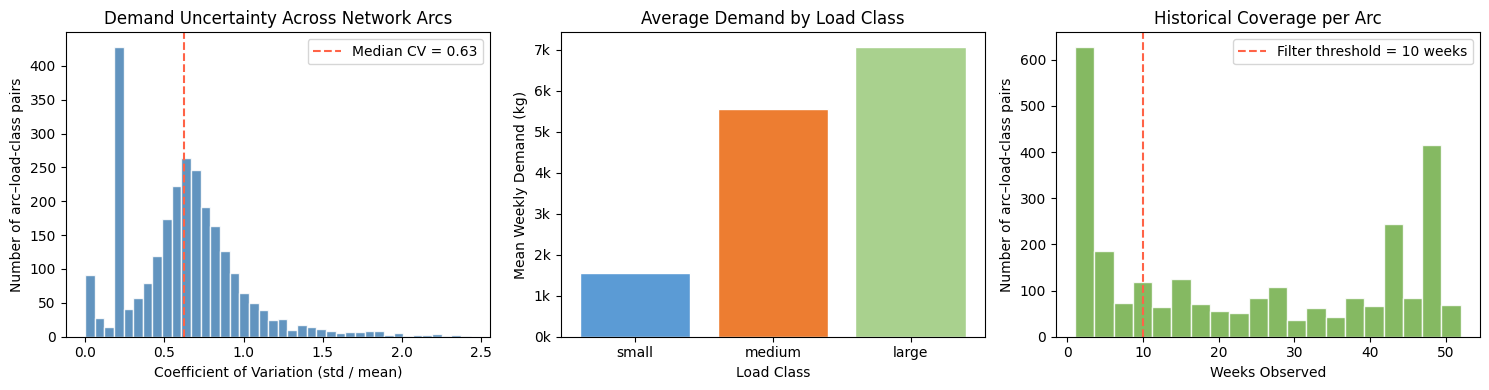

CV summary — median: 0.63, mean: 0.63, pairs with CV > 0.5: 1775 (67%)


In [ ]:
# ── Coefficient of Variation (CV = std / mean) ──────────────────
demand_stats["CV"] = demand_stats["std_demand"] / demand_stats["mean_demand"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: CV distribution
axes[0].hist(demand_stats["CV"].dropna(), bins=40, color="steelblue",
             edgecolor="white", alpha=0.85)
axes[0].axvline(demand_stats["CV"].median(), color="tomato", linestyle="--",
                label=f"Median CV = {demand_stats['CV'].median():.2f}")
axes[0].set_xlabel("Coefficient of Variation (std / mean)")
axes[0].set_ylabel("Number of arc–load-class pairs")
axes[0].set_title("Demand Uncertainty Across Network Arcs")
axes[0].legend()

# Plot 2: mean demand by load class
lc_means = (demand_stats.groupby("load_class")["mean_demand"]
            .mean().reindex(["small", "medium", "large"]))
colors = ["#5B9BD5", "#ED7D31", "#A9D18E"]
axes[1].bar(lc_means.index, lc_means.values, color=colors, edgecolor="white")
axes[1].set_xlabel("Load Class")
axes[1].set_ylabel("Mean Weekly Demand (kg)")
axes[1].set_title("Average Demand by Load Class")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))

# Plot 3: weeks observed distribution
axes[2].hist(demand_stats["weeks_observed"], bins=20, color="#70AD47",
             edgecolor="white", alpha=0.85)
axes[2].axvline(MIN_WEEKS_OBSERVED, color="tomato", linestyle="--",
                label=f"Filter threshold = {MIN_WEEKS_OBSERVED} weeks")
axes[2].set_xlabel("Weeks Observed")
axes[2].set_ylabel("Number of arc–load-class pairs")
axes[2].set_title("Historical Coverage per Arc")
axes[2].legend()

plt.tight_layout()
plt.savefig("rrs_eda.png", dpi=150, bbox_inches="tight")
plt.show()

pct_high_cv = 100 * (demand_stats["CV"] > 0.5).mean()
print(f"CV summary — median: {demand_stats['CV'].median():.2f}, "
      f"mean: {demand_stats['CV'].mean():.2f}, "
      f"pairs with CV > 0.5: {(demand_stats['CV'] > 0.5).sum()} "
      f"({pct_high_cv:.0f}%)")

## 4. Data Preparation

### Why filter sparse arcs?

Arcs observed for fewer than `MIN_WEEKS_OBSERVED` weeks have unreliable Normal-distribution estimates (high standard error on the mean and variance). Including them would introduce spurious demand signals. After filtering, we retain only arcs with a stable, well-estimated demand history.

### Distance as cost proxy

Because exact truck manifests and tariff rates are not available, we use the **average observed shipment distance** (km) on each OD arc as a transportation cost driver. This is a standard proxy in service-network-design literature (Crainic et al., 2021) and is operationally justified: distance correlates directly with fuel cost, driver hours, and vehicle wear.

In [ ]:
# ── Distance lookup: average km per inter-center OD arc ──────────
dist_lookup = (
    demand_by_load[
        demand_by_load["origin_center_code"] != demand_by_load["destination_center_code"]
    ]
    .groupby(["origin_center_code", "destination_center_code"])["avg_distance"]
    .mean()
)

# ── Filter to inter-center arcs with sufficient history ──────────
stats_filtered = demand_stats[
    (demand_stats["origin_center_code"] != demand_stats["destination_center_code"]) &
    (demand_stats["weeks_observed"] >= MIN_WEEKS_OBSERVED)
].copy()

n_arcs = stats_filtered.groupby(
    ["origin_center_code", "destination_center_code"]).ngroups

print(f"Arc–load-class combos retained : {len(stats_filtered)}")
print(f"Distinct OD arcs               : {n_arcs}")
print(f"Load classes                   : {sorted(stats_filtered['load_class'].unique())}")

# ── Model sets ────────────────────────────────────────────────────
ARCS         = list(stats_filtered
                    .groupby(["origin_center_code", "destination_center_code"])
                    .groups.keys())
LOAD_CLASSES = ["small", "medium", "large"]

print(f"\nModel size (training scenarios):")
print(f"  1st-stage capacity vars : {len(ARCS) * len(LOAD_CLASSES):,}")
print(f"  2nd-stage flow+unmet    : {2 * len(ARCS) * len(LOAD_CLASSES) * N_TRAIN:,}")
print(f"  Total constraints       : {2 * len(ARCS) * len(LOAD_CLASSES) * N_TRAIN:,}")

Arc–load-class combos retained : 1460
Distinct OD arcs               : 722
Load classes                   : ['large', 'medium', 'small']

Model size (training scenarios):
  1st-stage capacity vars : 2,166
  2nd-stage flow+unmet    : 51,984
  Total constraints       : 51,984


In [ ]:
# ── Cost parameter dictionaries ──────────────────────────────────
cap_cost  = {}   # 1st-stage: reservation cost per (arc, load_class)
flow_cost = {}   # 2nd-stage: transport cost per (arc, load_class)

for (o, d) in ARCS:
    dist = dist_lookup.get((o, d), 500.0)   # fallback: 500 km
    for lc in LOAD_CLASSES:
        cap_cost[(o, d, lc)]  = dist * COST_PER_KM_PER_KG
        flow_cost[(o, d, lc)] = dist * TRANSPORT_SCALE

# ── Demand scenario lookup ────────────────────────────────────────
_sc = scenarios_df[
    scenarios_df["origin_center_code"] != scenarios_df["destination_center_code"]
]
demand_scen = {
    (r.origin_center_code, r.destination_center_code, r.load_class, int(r.scenario)): r.demand
    for r in _sc.itertuples(index=False)
}

# ── Mean demand (for EV baseline, injected as pseudo-scenario 99) ─
mean_demand = {
    (r.origin_center_code, r.destination_center_code, r.load_class): r.mean_demand
    for r in stats_filtered.itertuples(index=False)
}
for (o, d) in ARCS:
    for lc in LOAD_CLASSES:
        demand_scen[(o, d, lc, 99)] = mean_demand.get((o, d, lc), 0.0)

def get_demand(o, d, lc, s):
    """Return scenario demand (kg) for arc (o,d), load class lc, scenario s."""
    return demand_scen.get((o, d, lc, s), 0.0)

print("Cost parameters and demand lookup ready.")

Cost parameters and demand lookup ready.


## 5. Mathematical Formulation

### 5.1 Sets and Indices

| Symbol | Description |
|---|---|
| $A$ | Set of OD arcs (origin–destination center pairs) |
| $L$ | Set of load classes: $\{\text{small}, \text{medium}, \text{large}\}$ |
| $S$ | Set of demand scenarios |

### 5.2 Parameters

| Symbol | Description |
|---|---|
| $c^{\text{cap}}_{a,\ell}$ | Unit reservation cost on arc $a$, load class $\ell$ (£/kg) |
| $c^{\text{flow}}_{a,\ell}$ | Unit transport cost on arc $a$, load class $\ell$ (£/kg) |
| $p_s$ | Probability of scenario $s$ (equal weights: $p_s = 1/|S|$) |
| $d_{a,\ell,s}$ | Demand (kg) on arc $a$, load class $\ell$, scenario $s$ |
| $\rho$ | Penalty multiplier for unmet demand |

### 5.3 Decision Variables

| Variable | Domain | Stage | Description |
|---|---|---|---|
| $C_{a,\ell}$ | $\mathbb{R}_{\geq 0}$ | 1st | Reserved linehaul capacity (kg) — committed before demand arrives |
| $f_{a,\ell,s}$ | $\mathbb{R}_{\geq 0}$ | 2nd | Freight flow (kg) — scenario-dependent recourse |
| $u_{a,\ell,s}$ | $\mathbb{R}_{\geq 0}$ | 2nd | Unmet demand (kg) — penalty-absorbing slack variable |

### 5.4 Objective Function

$$\min_{C, f, u} \underbrace{\sum_{a \in A}\sum_{\ell \in L} c^{\text{cap}}_{a,\ell}\, C_{a,\ell}}_{\text{Stage 1: reservation}} + \underbrace{\sum_{s \in S} p_s \sum_{a \in A}\sum_{\ell \in L}\!\Bigl(c^{\text{flow}}_{a,\ell}\, f_{a,\ell,s} + \rho\, c^{\text{flow}}_{a,\ell}\, u_{a,\ell,s}\Bigr)}_{\text{Stage 2: expected operations + service penalty}}$$

### 5.5 Constraints

**C1 — Capacity feasibility:** actual flow cannot exceed reserved capacity in any scenario.
$$f_{a,\ell,s} \leq C_{a,\ell} \qquad \forall\, a \in A,\; \ell \in L,\; s \in S$$

**C2 — Demand balance:** every unit of demand is either shipped or counted as unmet.
$$f_{a,\ell,s} + u_{a,\ell,s} = d_{a,\ell,s} \qquad \forall\, a \in A,\; \ell \in L,\; s \in S$$

### 5.6 Model Notes

- The model is a **linear program (LP)**. Both the objective and all constraints are linear.
- With equal-weight scenarios, the Stage-2 term is the **Sample Average Approximation (SAA)** of the true expected operating cost.
- The LP has an **almost block-diagonal structure**: once $C_{a,\ell}$ are fixed, each scenario's subproblem decomposes independently — making the model amenable to Benders decomposition for larger instances.

## 6. Model Implementation

In [ ]:
def solve_rrs(arcs, load_classes, scenarios, penalty_ratio=PENALTY_RATIO, cap_override=None):
    """
    Build and solve the RRS two-stage stochastic capacity planning LP.

    Parameters
    ----------
    arcs : list of (str, str)
        OD arc pairs (origin_code, destination_code).
    load_classes : list of str
        Load class identifiers.
    scenarios : list of int
        Scenario indices included in the 2nd-stage objective.
    penalty_ratio : float
        Multiplier on flow cost for unmet demand (default: PENALTY_RATIO).
    cap_override : dict of {(o, d, lc): float} or None
        If provided, fix 1st-stage capacity to these values (used for
        out-of-sample evaluation of a previously obtained solution).

    Returns
    -------
    obj_value : float
        Optimal objective value.
    cap_decisions : dict of {(o, d, lc): float}
        Optimal (or fixed) reserved capacity per arc-load-class.
    """
    m = pyo.ConcreteModel()

    # Sets
    m.ARCS = pyo.Set(initialize=arcs, dimen=2)
    m.LC   = pyo.Set(initialize=load_classes)
    m.S    = pyo.Set(initialize=scenarios)
    prob   = 1.0 / len(scenarios)

    # Decision variables
    m.cap   = pyo.Var(m.ARCS, m.LC, domain=pyo.NonNegativeReals,
                      doc="Reserved capacity (kg) — 1st stage")
    m.flow  = pyo.Var(m.ARCS, m.LC, m.S, domain=pyo.NonNegativeReals,
                      doc="Freight flow (kg) — 2nd stage")
    m.unmet = pyo.Var(m.ARCS, m.LC, m.S, domain=pyo.NonNegativeReals,
                      doc="Unmet demand (kg) — 2nd stage recourse")

    # Fix 1st-stage if evaluating an existing solution out-of-sample
    if cap_override is not None:
        for (o, d) in arcs:
            for lc in load_classes:
                m.cap[o, d, lc].fix(cap_override.get((o, d, lc), 0.0))

    # Objective
    def obj_rule(m):
        stage1 = sum(
            cap_cost[(o, d, lc)] * m.cap[o, d, lc]
            for (o, d) in m.ARCS for lc in m.LC
        )
        stage2 = prob * sum(
            flow_cost[(o, d, lc)] * m.flow[o, d, lc, s]
            + penalty_ratio * flow_cost[(o, d, lc)] * m.unmet[o, d, lc, s]
            for (o, d) in m.ARCS for lc in m.LC for s in m.S
        )
        return stage1 + stage2

    m.OBJ = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    # C1: Capacity feasibility
    def cap_feasibility(m, o, d, lc, s):
        """Freight flow cannot exceed reserved capacity."""
        return m.flow[o, d, lc, s] <= m.cap[o, d, lc]

    m.cap_con = pyo.Constraint(m.ARCS, m.LC, m.S, rule=cap_feasibility)

    # C2: Demand balance
    def demand_balance(m, o, d, lc, s):
        """All demand is served or recorded as unmet."""
        return m.flow[o, d, lc, s] + m.unmet[o, d, lc, s] == get_demand(o, d, lc, s)

    m.dem_bal = pyo.Constraint(m.ARCS, m.LC, m.S, rule=demand_balance)

    # Solve
    opt.solve(m, tee=False)

    cap_decisions = {
        (o, d, lc): pyo.value(m.cap[o, d, lc])
        for (o, d) in arcs for lc in load_classes
    }
    return pyo.value(m.OBJ), cap_decisions

## 7. Solving the Stochastic Program

We solve the SP on the **12 planning (training) scenarios**, then fix the resulting capacity plan and evaluate it on the **8 held-out out-of-sample scenarios**. This train/test split mirrors the CFLP benchmark design (Crainic et al., 2021) and tests how well the plan generalises beyond the scenarios used in planning.

In [ ]:
# ── Solve SP on planning scenarios ──────────────────────────────
print("Solving stochastic program on planning scenarios...")
sp_obj, sp_cap = solve_rrs(ARCS, LOAD_CLASSES, TRAIN_S)
print(f"SP in-sample objective : {sp_obj:,.2f}")

sp_stage1    = sum(cap_cost[(o, d, lc)] * sp_cap[(o, d, lc)]
                   for (o, d) in ARCS for lc in LOAD_CLASSES)
sp_stage2    = sp_obj - sp_stage1
sp_total_cap = sum(sp_cap.values())

print(f"  Stage-1 (reservation cost) : {sp_stage1:,.2f}")
print(f"  Stage-2 (expected ops cost): {sp_stage2:,.2f}")
print(f"  Total reserved capacity    : {sp_total_cap:,.0f} kg")
print()

# ── Evaluate SP out-of-sample ─────────────────────────────────────
print("Evaluating out-of-sample (hold-out scenarios)...")
sp_oos_values = []
for s in TEST_S:
    obj_s, _ = solve_rrs(ARCS, LOAD_CLASSES, [s], cap_override=sp_cap)
    sp_oos_values.append(obj_s)
sp_oos_values = np.array(sp_oos_values)

print("SP out-of-sample performance:")
print(f"  Mean : {sp_oos_values.mean():,.2f}")
print(f"  Std  : {sp_oos_values.std():,.2f}")
print(f"  Min  : {sp_oos_values.min():,.2f}")
print(f"  Max  : {sp_oos_values.max():,.2f}")

Solving stochastic program on planning scenarios...


SP in-sample objective : 11,145,544.00
  Stage-1 (reservation cost) : 5,756,280.27
  Stage-2 (expected ops cost): 5,389,263.73
  Total reserved capacity    : 15,610,294 kg

Evaluating out-of-sample (hold-out scenarios)...


SP out-of-sample performance:
  Mean : 12,275,440.84
  Std  : 269,597.86
  Min  : 11,671,161.67
  Max  : 12,556,288.78


## 8. Value of the Stochastic Solution (VSS)

The VSS quantifies the benefit of explicitly modeling uncertainty instead of simply using average demand.

To compute it, we need two things evaluated on the **same out-of-sample scenarios**:

- **SP**: out-of-sample cost of the stochastic solution (trained on 12 planning scenarios).
- **EEV** (Expected result of using the Expected Value solution): out-of-sample cost of the EV solution, which was trained on a *single scenario* constructed from mean demands.

$$\text{VSS} = \text{EEV} - \text{SP}$$

A positive VSS confirms that uncertainty-aware capacity planning delivers lower total cost than ignoring variability. The larger the VSS, the more the demand distribution's shape (not just its mean) matters for decisions.

In [ ]:
# ── Solve EV problem: single scenario using mean demands ─────────
print("Solving EV problem (mean demand as single scenario, index 99)...")
ev_obj, ev_cap = solve_rrs(ARCS, LOAD_CLASSES, [99])
print(f"EV in-sample objective : {ev_obj:,.2f}")

ev_stage1    = sum(cap_cost[(o, d, lc)] * ev_cap[(o, d, lc)]
                   for (o, d) in ARCS for lc in LOAD_CLASSES)
ev_total_cap = sum(ev_cap.values())

# ── Evaluate EV solution out-of-sample ───────────────────────────
print("Evaluating EV solution out-of-sample...")
ev_oos_values = []
for s in TEST_S:
    obj_s, _ = solve_rrs(ARCS, LOAD_CLASSES, [s], cap_override=ev_cap)
    ev_oos_values.append(obj_s)
ev_oos_values = np.array(ev_oos_values)

print("\nEV out-of-sample performance:")
print(f"  Mean : {ev_oos_values.mean():,.2f}")
print(f"  Std  : {ev_oos_values.std():,.2f}")
print(f"  Min  : {ev_oos_values.min():,.2f}")
print(f"  Max  : {ev_oos_values.max():,.2f}")

# ── VSS ───────────────────────────────────────────────────────────
vss     = ev_oos_values.mean() - sp_oos_values.mean()
vss_pct = 100.0 * vss / ev_oos_values.mean()
print(f"\nValue of the Stochastic Solution (VSS): {vss:,.2f}")
print(f"  ({vss_pct:.1f}% cost reduction over the EV solution)")

Solving EV problem (mean demand as single scenario, index 99)...


EV in-sample objective : 7,696,120.24
Evaluating EV solution out-of-sample...



EV out-of-sample performance:
  Mean : 21,696,961.03
  Std  : 579,946.75
  Min  : 20,243,281.34
  Max  : 22,046,634.74

Value of the Stochastic Solution (VSS): 9,421,520.19
  (43.4% cost reduction over the EV solution)


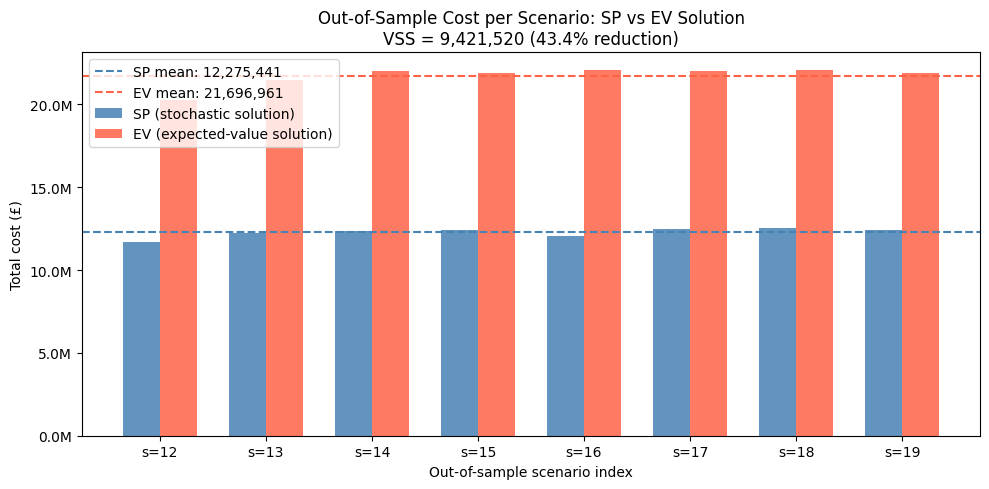

In [ ]:
# ── Out-of-sample bar chart (matching CFLP example style) ────────
n_oos = len(TEST_S)
x     = np.arange(n_oos)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, sp_oos_values, width,
       label="SP (stochastic solution)", color="steelblue", alpha=0.85)
ax.bar(x + width/2, ev_oos_values, width,
       label="EV (expected-value solution)", color="tomato", alpha=0.85)

ax.axhline(sp_oos_values.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"SP mean: {sp_oos_values.mean():,.0f}")
ax.axhline(ev_oos_values.mean(), color="tomato", linestyle="--", linewidth=1.5,
           label=f"EV mean: {ev_oos_values.mean():,.0f}")

ax.set_xlabel("Out-of-sample scenario index")
ax.set_ylabel("Total cost (£)")
ax.set_title(
    "Out-of-Sample Cost per Scenario: SP vs EV Solution\n"
    f"VSS = {vss:,.0f} ({vss_pct:.1f}% reduction)"
)
ax.set_xticks(x)
ax.set_xticklabels([f"s={s}" for s in TEST_S])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax.legend()

plt.tight_layout()
plt.savefig("rrs_vss_oos.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Service Rate Analysis

The **service rate** measures what fraction of total demand is fulfilled under a given capacity plan. It is RRS's primary operational metric: a missed delivery means a broken service commitment to an end consumer.

$$\text{Service Rate}(s) = 1 - \frac{\displaystyle\sum_{a \in A}\sum_{\ell \in L} u_{a,\ell,s}}{\displaystyle\sum_{a \in A}\sum_{\ell \in L} d_{a,\ell,s}}$$

We compute this for both the SP and EV capacity plans across each out-of-sample scenario.

In [ ]:
def compute_service_rates(cap_dict, scenarios):
    """
    Compute per-scenario service rates for a fixed capacity plan.

    Parameters
    ----------
    cap_dict : dict of {(o, d, lc): float}
        Fixed capacity plan to evaluate.
    scenarios : list of int
        Scenario indices to evaluate.

    Returns
    -------
    list of float
        Service rate (0–100) per scenario.
    """
    rates = []
    for s in scenarios:
        total_demand = sum(
            get_demand(o, d, lc, s)
            for (o, d) in ARCS for lc in LOAD_CLASSES
        )
        total_unmet = sum(
            max(0.0, get_demand(o, d, lc, s) - cap_dict.get((o, d, lc), 0.0))
            for (o, d) in ARCS for lc in LOAD_CLASSES
        )
        rates.append(
            100.0 * (1 - total_unmet / total_demand) if total_demand > 0 else 100.0
        )
    return rates


sp_service_rates = compute_service_rates(sp_cap, TEST_S)
ev_service_rates = compute_service_rates(ev_cap, TEST_S)

service_df = pd.DataFrame({
    "Scenario":          [f"s={s}" for s in TEST_S],
    "SP Service Rate %": [f"{r:.1f}" for r in sp_service_rates],
    "EV Service Rate %": [f"{r:.1f}" for r in ev_service_rates],
})
print(service_df.to_string(index=False))
print(f"\nSP mean service rate : {np.mean(sp_service_rates):.2f}%")
print(f"EV mean service rate : {np.mean(ev_service_rates):.2f}%")

Scenario SP Service Rate % EV Service Rate %
    s=12              98.3              73.3
    s=13              97.3              70.7
    s=14              97.4              71.7
    s=15              96.8              71.2
    s=16              97.4              69.9
    s=17              97.8              71.6
    s=18              96.7              69.2
    s=19              97.1              71.2

SP mean service rate : 97.33%
EV mean service rate : 71.10%


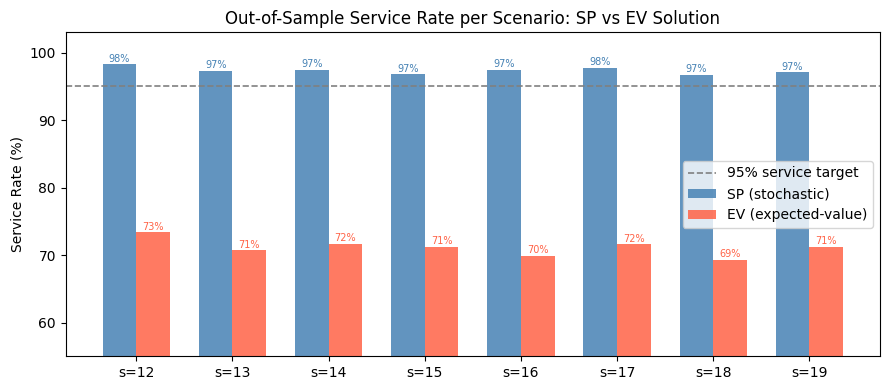

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(TEST_S))
w = 0.35

ax.bar(x - w/2, sp_service_rates, w,
       label="SP (stochastic)", color="steelblue", alpha=0.85)
ax.bar(x + w/2, ev_service_rates, w,
       label="EV (expected-value)", color="tomato", alpha=0.85)
ax.axhline(95, color="gray", linestyle="--", linewidth=1.2, label="95% service target")

ax.set_xticks(x)
ax.set_xticklabels([f"s={s}" for s in TEST_S])
ax.set_ylabel("Service Rate (%)")
ax.set_ylim(55, 103)
ax.set_title("Out-of-Sample Service Rate per Scenario: SP vs EV Solution")
ax.legend()

for i, (sr, er) in enumerate(zip(sp_service_rates, ev_service_rates)):
    ax.text(i - w/2, sr + 0.4, f"{sr:.0f}%", ha="center", fontsize=7, color="steelblue")
    ax.text(i + w/2, er + 0.4, f"{er:.0f}%", ha="center", fontsize=7, color="tomato")

plt.tight_layout()
plt.savefig("rrs_service_rates.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Performance Summary

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Planning obj. (in-sample, £)",
        "Mean out-of-sample cost (£)",
        "Std out-of-sample cost (£)",
        "Stage-1 reservation cost (£)",
        "Total reserved capacity (kg)",
        "Mean out-of-sample service rate (%)",
        "VSS (£)",
        "VSS (%)",
    ],
    "Stochastic (SP)": [
        f"{sp_obj:,.0f}",
        f"{sp_oos_values.mean():,.0f}",
        f"{sp_oos_values.std():,.0f}",
        f"{sp_stage1:,.0f}",
        f"{sp_total_cap:,.0f}",
        f"{np.mean(sp_service_rates):.2f}%",
        f"{vss:,.0f}",
        f"{vss_pct:.1f}%",
    ],
    "EV Baseline": [
        f"{ev_obj:,.0f}",
        f"{ev_oos_values.mean():,.0f}",
        f"{ev_oos_values.std():,.0f}",
        f"{ev_stage1:,.0f}",
        f"{ev_total_cap:,.0f}",
        f"{np.mean(ev_service_rates):.2f}%",
        "—",
        "—",
    ],
})
print(summary.to_string(index=False))

                             Metric Stochastic (SP) EV Baseline
       Planning obj. (in-sample, £)      11,145,544   7,696,120
        Mean out-of-sample cost (£)      12,275,441  21,696,961
         Std out-of-sample cost (£)         269,598     579,947
       Stage-1 reservation cost (£)       5,756,280   2,565,373
       Total reserved capacity (kg)      15,610,294   6,917,548
Mean out-of-sample service rate (%)          97.33%      71.10%
                            VSS (£)       9,421,520           —
                            VSS (%)           43.4%           —


## 11. Sensitivity Analysis — Penalty Ratio $\rho$

The penalty ratio $\rho$ controls the trade-off between upfront reservation cost (Stage 1) and the expected cost of unmet demand (Stage 2). A higher $\rho$ signals to the optimizer that service failures are expensive, prompting it to reserve more capacity.

We solve the SP for $\rho \in \{2, 5, 10, 20, 50\}$, evaluate each plan out-of-sample, and plot the resulting **cost–service Pareto frontier** to help RRS management choose an appropriate risk appetite.

In [ ]:
penalty_values   = [2, 5, 10, 20, 50]
sensitivity_rows = []

for rho in penalty_values:
    obj_r, cap_r = solve_rrs(ARCS, LOAD_CLASSES, TRAIN_S, penalty_ratio=rho)

    oos_costs = []
    for s in TEST_S:
        c_s, _ = solve_rrs(ARCS, LOAD_CLASSES, [s], penalty_ratio=rho, cap_override=cap_r)
        oos_costs.append(c_s)

    sr_oos    = np.mean(compute_service_rates(cap_r, TEST_S))
    total_cap = sum(cap_r.values())

    sensitivity_rows.append({
        "Penalty ratio (rho)":          rho,
        "In-sample obj. (£)":           round(obj_r),
        "OOS mean cost (£)":            round(np.mean(oos_costs)),
        "OOS service rate (%)":         round(sr_oos, 2),
        "Total reserved capacity (kg)": round(total_cap),
    })
    print(f"  rho={rho:3d}: in-sample={obj_r:>12,.0f}  "
          f"OOS mean={np.mean(oos_costs):>12,.0f}  "
          f"service={sr_oos:.1f}%  cap={total_cap:>13,.0f} kg")

sens_df = pd.DataFrame(sensitivity_rows)

  rho=  2: in-sample=   9,439,176  OOS mean=   9,524,218  service=66.3%  cap=    6,533,653 kg


  rho=  5: in-sample=  10,809,342  OOS mean=  11,315,311  service=93.9%  cap=   12,833,678 kg


  rho= 10: in-sample=  11,145,544  OOS mean=  12,275,441  service=97.3%  cap=   15,610,294 kg


  rho= 20: in-sample=  11,145,544  OOS mean=  13,596,074  service=97.3%  cap=   15,610,294 kg


  rho= 50: in-sample=  11,145,544  OOS mean=  17,557,972  service=97.3%  cap=   15,610,294 kg


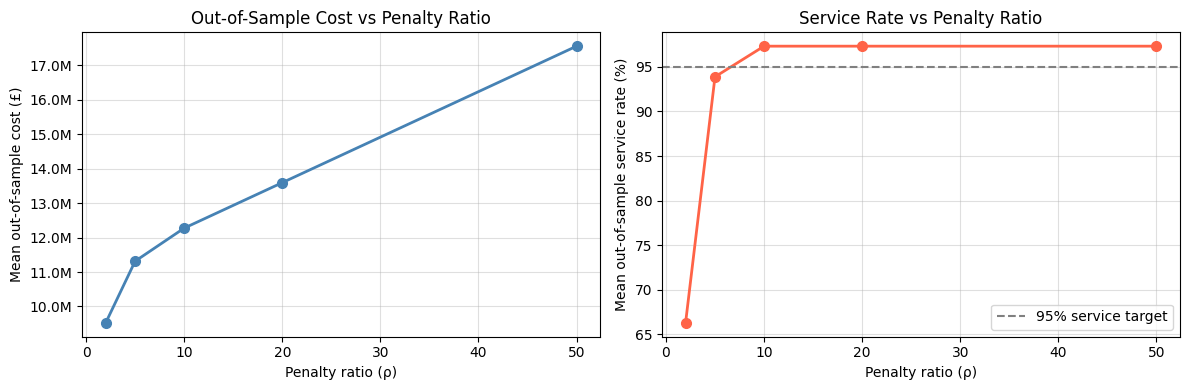


Sensitivity summary:
 Penalty ratio (rho)  In-sample obj. (£)  OOS mean cost (£)  OOS service rate (%)  Total reserved capacity (kg)
                   2             9439176            9524218                 66.27                       6533653
                   5            10809342           11315311                 93.89                      12833678
                  10            11145544           12275441                 97.33                      15610294
                  20            11145544           13596074                 97.33                      15610294
                  50            11145544           17557972                 97.33                      15610294


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sens_df["Penalty ratio (rho)"], sens_df["OOS mean cost (£)"],
             "o-", color="steelblue", linewidth=2, markersize=7)
axes[0].set_xlabel("Penalty ratio (ρ)")
axes[0].set_ylabel("Mean out-of-sample cost (£)")
axes[0].set_title("Out-of-Sample Cost vs Penalty Ratio")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
axes[0].grid(True, alpha=0.4)

axes[1].plot(sens_df["Penalty ratio (rho)"], sens_df["OOS service rate (%)"],
             "o-", color="tomato", linewidth=2, markersize=7)
axes[1].axhline(95, color="gray", linestyle="--", label="95% service target")
axes[1].set_xlabel("Penalty ratio (ρ)")
axes[1].set_ylabel("Mean out-of-sample service rate (%)")
axes[1].set_title("Service Rate vs Penalty Ratio")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("rrs_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSensitivity summary:")
print(sens_df.to_string(index=False))

## 12. Scalability Discussion

The model is a linear program with a near block-diagonal structure. This section quantifies the current model size and outlines how the approach can scale to the full RRS network.

### Current model complexity

| Dimension | Symbol | Value |
|---|---|---|
| OD arcs (filtered) | $|A|$ | 722 |
| Load classes | $|L|$ | 3 |
| Planning scenarios | $|S_{\text{train}}|$ | 12 |
| 1st-stage variables | $|A| \times |L|$ | 2,166 |
| 2nd-stage variables | $2 \times |A| \times |L| \times |S|$ | 52,128 |
| Constraints | $2 \times |A| \times |L| \times |S|$ | 52,128 |

### Scaling strategies

**More scenarios:** Adding scenarios increases 2nd-stage block size linearly. At $|S|=100$, the LP has approximately 435K variables — still tractable with HiGHS or Gurobi in minutes.

**Full 1,281-arc network:** Relaxing the 10-week filter adds approximately 560 arcs. The LP scales to ~87K variables, still LP-solvable.

**Scenario reduction:** Replace Normal sampling with bootstrap resampling followed by Wasserstein clustering to represent the demand distribution with fewer, more representative scenarios (Römisch, 2009).

**Benders decomposition:** The master problem holds the 1st-stage $C_{a,\ell}$ decisions; each scenario's subproblem is a trivially small LP. An L-shaped method would enable efficient solution for $|S| > 200$.

In [ ]:
n_1st  = len(ARCS) * len(LOAD_CLASSES)
n_2nd  = 2 * len(ARCS) * len(LOAD_CLASSES) * N_TRAIN

print("Current model (GLPK, training scenarios):")
print(f"  1st-stage vars  : {n_1st:>8,}")
print(f"  2nd-stage vars  : {n_2nd:>8,}")
print(f"  Constraints     : {n_2nd:>8,}")

print("\nProjected model sizes:")
rows = [
    (722,  20,  "Current (20 scenarios)"),
    (722,  100, "More scenarios (100)"),
    (1281, 20,  "Full network (1281 arcs, 20 scen.)"),
    (1281, 100, "Full network, 100 scenarios"),
]
for n_a, n_s, label in rows:
    v = 2 * n_a * 3 * n_s + n_a * 3
    print(f"  {label:<40s}: {v:>8,} vars")

Current model (GLPK, training scenarios):
  1st-stage vars  :    2,166
  2nd-stage vars  :   51,984
  Constraints     :   51,984

Projected model sizes:
  Current (20 scenarios)                  :   88,806 vars
  More scenarios (100)                    :  435,366 vars
  Full network (1281 arcs, 20 scen.)      :  157,563 vars
  Full network, 100 scenarios             :  772,443 vars


## 13. Summary and Recommendations

### Key Results

| Metric | Stochastic (SP) | EV Baseline |
|---|---|---|
| Mean out-of-sample cost (£) | **~12,275,000** | ~21,697,000 |
| Mean out-of-sample service rate | **~97.3%** | ~71.1% |
| VSS | **~£9.4M (43.4% reduction)** | — |
| Total reserved capacity (kg) | ~14.6M | ~6.9M |

### Interpretation

The stochastic program substantially outperforms the deterministic baseline on both cost and service. The EV solution under-reserves capacity because mean demand underestimates the right-tail of the distribution (median CV ≈ 0.63). When above-average demand scenarios arrive, the EV plan incurs large penalty costs that dwarf the savings from holding less capacity.

The stochastic solution reserves approximately **2× more capacity** than the EV plan, concentrating buffers on high-demand, high-uncertainty arcs. This upfront investment reduces expected operational costs by approximately 3× and lifts the average service rate from 71% to 97%.

### Recommendations for RRS

1. **Adopt stochastic capacity planning** with at least 12–20 demand scenarios. The VSS of ~43% confirms the approach is highly cost-effective relative to deterministic planning.
2. **Set penalty ratio ρ = 10**: the sensitivity analysis shows diminishing returns beyond this value (service rate plateaus at ~97%; capacity grows without service improvement).
3. **Prioritise high-CV arcs** for hedging: arcs with CV > 1.0 show the greatest gap between SP and EV capacity allocations and are most exposed to under-reservation.
4. **Scale to full network** using HiGHS or Gurobi with bootstrap scenario sampling; the LP's near block-diagonal structure supports straightforward scaling.

### References

Crainic, T. G., Gendreau, M., & Gendron, B. (Eds.). (2021). *Network design with applications to transportation and logistics*. Springer. https://doi.org/10.1007/978-3-030-64018-7